# Control voltages 
Example using and testing the control voltages module. Main purpose is to compute the desired active coil voltages for a given set of target shifts, using virtual circuits.
- setting up an equi, computing and saving some VCs.
- computing voltages with default VC params
- computing voltages with VC's loaded from file 



In [44]:
### IMPORTS ###
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time 
import os 
import pickle 


%load_ext autoreload
%autoreload 2


## set machine config paths 

os.environ["ACTIVE_COILS_PATH"] = (
    f"/Users/alasdair.ross/Documents/HARTREE/freegsnke_starters/machine_data/MAST-U_active_coils.pickle"
)
os.environ["PASSIVE_COILS_PATH"] = (
    f"/Users/alasdair.ross/Documents/HARTREE/freegsnke_starters/machine_data/MAST-U_passive_coils.pickle"
)
os.environ["WALL_PATH"] = (
    f"/Users/alasdair.ross/Documents/HARTREE/freegsnke_starters/machine_data/MAST-U_wall.pickle"
)
os.environ["LIMITER_PATH"] = (
    f"/Users/alasdair.ross/Documents/HARTREE/freegsnke_starters/machine_data/MAST-U_limiter.pickle"
)

# freesgnke imports (after env variables set)
from freegsnke import machine_config
from freegsnke import virtual_circuits as vc
from freegsnke.nonlinear_solve import nl_solver

from freegs4e.plotting import plotEquilibrium as plot_eqi



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## creating and saving some VC's 
First we need some example equilibria and vc's for these. We need an equilibrium object and a profiles object, and also a non linear solver object.





In [45]:
from freegs4e.gradshafranov import mu0  # permeability
from freegsnke import GSstaticsolver, build_machine, equilibrium_update, jtor_update
from freegsnke import virtual_circuits as vc
from freegsnke.jtor_update import Lao85


def create_equilibrium(plasma_psi=None) -> tuple:

    tokamak = build_machine.tokamak()

    eq = equilibrium_update.Equilibrium(
        tokamak=tokamak,  # provide tokamak object
        Rmin=0.1,
        Rmax=2.0,  # radial range
        Zmin=-2.2,
        Zmax=2.2,  # vertical range
        nx=129,  # number of grid points in the radial direction (needs to be of the form (2**n + 1) with n being an integer)
        ny=129,  # number of grid points in the vertical direction (needs to be of the form (2**n + 1) with n being an integer)
        # psi=plasma_psi
    )

    alpha = np.array([1, 0, -1])
    beta = (1 - 0.3) / 0.3 * alpha * mu0

    profiles = Lao85(
        eq=eq,
        limiter=tokamak.limiter,
        Ip=6e5,
        fvac=0.5,
        alpha=alpha,
        beta=beta,
        alpha_logic=False,
        beta_logic=False,
        Ip_logic=True,
    )

    # Define solver
    GSStaticSolver = GSstaticsolver.NKGSsolver(eq)

    return eq, profiles, GSStaticSolver


# base equi and profiles and solver - contains machine informatoin and greens functions
eq, profiles, solver = create_equilibrium()
GSStaticSolver = GSstaticsolver.NKGSsolver(eq)

No probe configuration is provided


Now load some example equilibrium data, and solve for some equilibria. Save in a list of eqi's.

In [46]:
data = pd.read_csv(
    "/Users/alasdair.ross/Documents/HARTREE/Papers/emu_ieee/Nico_comparison/filtered_fgs_3sig_fgs.csv"
)
data = data.iloc[:10]

full_coil_list = list(eq.tokamak.getCurrents().keys())[:12]
data_currents = (
    data.loc[
        :,
        [
            "input/Solenoid",
            "input/px",
            "input/d1",
            "input/d2",
            "input/d3",
            "input/dp",
            "input/d5",
            "input/d6",
            "input/d7",
            "input/p4",
            "input/p5",
            "input/p6",
        ],
    ]
).to_numpy()
data_profiles = (
    data.loc[
        :,
        [
            "input/Ip",
            "input/alpha0",
            "input/alpha1",
            "input/beta0",
            "input/beta1",
            "input/fvac",
        ],
    ]
).to_numpy()
data_targets = (
    data.loc[
        :,
        [
            "target/Rin",
            "target/Rout",
            "target/Rxd",
            "target/Zxd",
            "target/strike_mid_X",
        ],
    ]
).to_numpy()


def load_from_table(index, eq=eq, psi0=None):

    if psi0 is not None:
        eq.plasma_psi = 1.0 * psi0

    for i, coil in enumerate(full_coil_list):
        eq.tokamak[coil].current = data_currents[index, i]

    profiles = Lao85(
        eq=eq,
        limiter=eq.tokamak.limiter,
        Ip=data_profiles[index, 0],
        fvac=data_profiles[index, -1],
        alpha=data_profiles[index, 1:3],
        beta=data_profiles[index, 3:5],
        alpha_logic=True,
        beta_logic=True,
        Ip_logic=True,
    )

    # call the solver
    GSStaticSolver.forward_solve(
        eq=eq,
        profiles=profiles,
        target_relative_tolerance=1e-9,
        verbose=False,  # print output
    )

    return eq, profiles

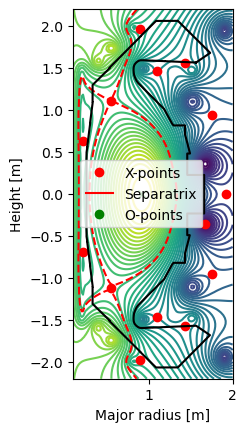

{'Solenoid': -15521.061278574336, 'px': 2016.2630220011315, 'd1': 3973.776334855837, 'd2': 4942.28070509305, 'd3': -2087.3755132032184, 'dp': -3771.631106105988, 'd5': -2018.3430809946824, 'd6': -446.8049220349658, 'd7': 1202.4723264410804, 'p4': -3388.909018187745, 'p5': -5610.990504739633, 'p6': -47.29386867855885, 'vessel_1': 0, 'vessel_2': 0, 'vessel_3': 0, 'vessel_4': 0, 'vessel_5': 0, 'vessel_6': 0, 'vessel_7': 0, 'vessel_8': 0, 'vessel_9': 0, 'vessel_10': 0, 'vessel_11': 0, 'vessel_12': 0, 'vessel_13': 0, 'vessel_14': 0, 'vessel_15': 0, 'vessel_16': 0, 'vessel_17': 0, 'vessel_18': 0, 'vessel_19': 0, 'vessel_20': 0, 'vessel_21': 0, 'vessel_22': 0, 'centrecolumn_1': 0, 'centrecolumn_2': 0, 'centrecolumn_3': 0, 'centrecolumn_4': 0, 'centrecolumn_5': 0, 'centrecolumn_6': 0, 'centrecolumn_7': 0, 'centrecolumn_8': 0, 'centrecolumn_9': 0, 'centrecolumn_10': 0, 'd1_support_upper_1': 0, 'd1_support_upper_2': 0, 'd1_support_upper_3': 0, 'd1_support_lower_1': 0, 'd1_support_lower_2': 0, 'd

In [47]:
eqi_list = []
profiles_list = []
for i in range(4):
    eq, profiles = load_from_table(i)
    eqi_list.append(eq)
    profiles_list.append(profiles)

# for j in range(5):
#     plot_eqi(eqi_list[j], show=True)

plot_eqi(eqi_list[3], show=True)
print(eqi_list[3].tokamak.getCurrents())

with this set of equilibria we can compute the VC's and save their info in a pickle file. Note that here i've given a list of currents that is not the full set of active coils in mast u and also not the standard ordering. This is to demonstrate robustness of the voltage control class


## Testing Voltage control class code 
We'll start by computing a set of voltages for a given equilibrium and profile object, without passing in a VC object. If no VC object is passed in, the class will build one using the VC class in freegsnke. 
Then we'll test this by giving different sets of targets and currents, again with no input VC object.
Finally we'll load a sequence of VC objects from a pickle file, and use them to obtain voltages.

SETUP 
- import the control voltages module, set some example targets currents and equi. also define stepping object here.
- import the scheduler module, and set up a scheduler object which defines the sequence of targets and vc's to be used in the simulation.

TESTING
- create an instance of the TargetSequencer class, with paths provided to pickle files with VC's, target sequence and target schedule.
- create an instance of the ControlVoltages class. We instantiate this with an equilibrium, set of profiles, and a stepping object, and also the target sequencer above. There are options to define the coils to use in the control.
- calculate the voltages using the calculate_feedback_voltage_vector function. This returns a tuple of voltages for the active coils.

In [48]:
import freegsnke.control_loop.control_voltages as cv
import freegsnke.control_loop.scheduler as scheduler


# choose example eqi from lst
eq_1 = eqi_list[0]
profiles_1 = profiles_list[0]

# non linear solver
stepper = nl_solver(
    profiles=profiles_1,
    eq=eq_1,
    mode_removal=False,
    linearize=False,
)

Input 'max_mode_frequency' corresponds to 16 independent passive structure normal modes (in addition to the 12 active coils).
The solver's timestep has been set to 0.0001 as explicitly requested. Please compare this with the linear growth rate and reset if necessary.


### Target and VC sequence

- we want to save the desired target values at various times along a shot and then extract target at a certain time by interpolation between the saved values.

- we'll save this as a dictionary into a pickle file, and then  use the target_sequence class to load this data and then compute the desired target at a given time.

as an example, lets use the targets computed in the VC sequence example




doing equilibrium 0 from list
{'Solenoid': -15521.061278574336, 'px': 2016.2630220011315, 'd1': 3973.776334855837, 'd2': 4942.28070509305, 'd3': -2087.3755132032184, 'dp': -3771.631106105988, 'd5': -2018.3430809946824, 'd6': -446.8049220349658, 'd7': 1202.4723264410804, 'p4': -3388.909018187745, 'p5': -5610.990504739633, 'p6': -47.29386867855885, 'vessel_1': 0, 'vessel_2': 0, 'vessel_3': 0, 'vessel_4': 0, 'vessel_5': 0, 'vessel_6': 0, 'vessel_7': 0, 'vessel_8': 0, 'vessel_9': 0, 'vessel_10': 0, 'vessel_11': 0, 'vessel_12': 0, 'vessel_13': 0, 'vessel_14': 0, 'vessel_15': 0, 'vessel_16': 0, 'vessel_17': 0, 'vessel_18': 0, 'vessel_19': 0, 'vessel_20': 0, 'vessel_21': 0, 'vessel_22': 0, 'centrecolumn_1': 0, 'centrecolumn_2': 0, 'centrecolumn_3': 0, 'centrecolumn_4': 0, 'centrecolumn_5': 0, 'centrecolumn_6': 0, 'centrecolumn_7': 0, 'centrecolumn_8': 0, 'centrecolumn_9': 0, 'centrecolumn_10': 0, 'd1_support_upper_1': 0, 'd1_support_upper_2': 0, 'd1_support_upper_3': 0, 'd1_support_lower_1': 

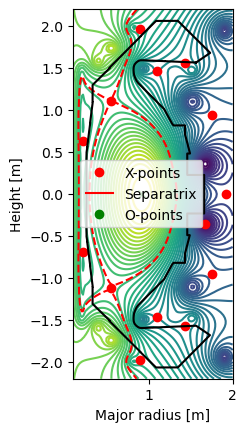

Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
More than four strikepoints located, use of 'target_option' input for Rs_lower_outer is strongly advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
More than four strikepoints located, use of 'target_option' input for Rs_lower_outer is strongly advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
More than four strikepoints located, use of 'target_option' input for Rs_lower_outer is strongly advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
More than four strikepoints located, use of 'target_option' input for Rs_lower_outer is strongly advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' inp

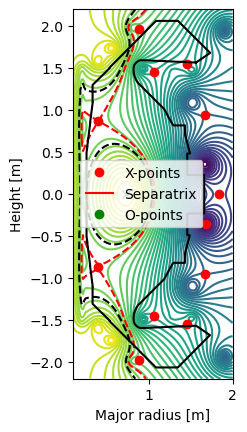

{'Solenoid': -15521.061278574336, 'px': 2016.2630220011315, 'd1': 3973.776334855837, 'd2': 4942.28070509305, 'd3': -2087.3755132032184, 'dp': -3771.631106105988, 'd5': -2018.3430809946824, 'd6': -446.8049220349658, 'd7': 1202.4723264410804, 'p4': -3388.909018187745, 'p5': -5610.990504739633, 'p6': -47.29386867855885, 'vessel_1': 0, 'vessel_2': 0, 'vessel_3': 0, 'vessel_4': 0, 'vessel_5': 0, 'vessel_6': 0, 'vessel_7': 0, 'vessel_8': 0, 'vessel_9': 0, 'vessel_10': 0, 'vessel_11': 0, 'vessel_12': 0, 'vessel_13': 0, 'vessel_14': 0, 'vessel_15': 0, 'vessel_16': 0, 'vessel_17': 0, 'vessel_18': 0, 'vessel_19': 0, 'vessel_20': 0, 'vessel_21': 0, 'vessel_22': 0, 'centrecolumn_1': 0, 'centrecolumn_2': 0, 'centrecolumn_3': 0, 'centrecolumn_4': 0, 'centrecolumn_5': 0, 'centrecolumn_6': 0, 'centrecolumn_7': 0, 'centrecolumn_8': 0, 'centrecolumn_9': 0, 'centrecolumn_10': 0, 'd1_support_upper_1': 0, 'd1_support_upper_2': 0, 'd1_support_upper_3': 0, 'd1_support_lower_1': 0, 'd1_support_lower_2': 0, 'd

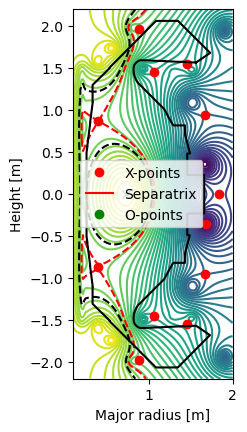

Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_optio

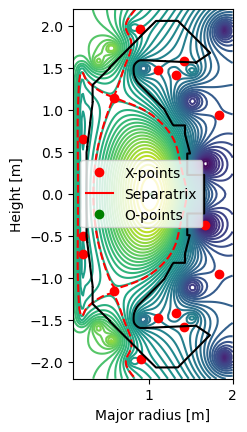

{'Solenoid': -15521.061278574336, 'px': 2016.2630220011315, 'd1': 3973.776334855837, 'd2': 4942.28070509305, 'd3': -2087.3755132032184, 'dp': -3771.631106105988, 'd5': -2018.3430809946824, 'd6': -446.8049220349658, 'd7': 1202.4723264410804, 'p4': -3388.909018187745, 'p5': -5610.990504739633, 'p6': -47.29386867855885, 'vessel_1': 0, 'vessel_2': 0, 'vessel_3': 0, 'vessel_4': 0, 'vessel_5': 0, 'vessel_6': 0, 'vessel_7': 0, 'vessel_8': 0, 'vessel_9': 0, 'vessel_10': 0, 'vessel_11': 0, 'vessel_12': 0, 'vessel_13': 0, 'vessel_14': 0, 'vessel_15': 0, 'vessel_16': 0, 'vessel_17': 0, 'vessel_18': 0, 'vessel_19': 0, 'vessel_20': 0, 'vessel_21': 0, 'vessel_22': 0, 'centrecolumn_1': 0, 'centrecolumn_2': 0, 'centrecolumn_3': 0, 'centrecolumn_4': 0, 'centrecolumn_5': 0, 'centrecolumn_6': 0, 'centrecolumn_7': 0, 'centrecolumn_8': 0, 'centrecolumn_9': 0, 'centrecolumn_10': 0, 'd1_support_upper_1': 0, 'd1_support_upper_2': 0, 'd1_support_upper_3': 0, 'd1_support_lower_1': 0, 'd1_support_lower_2': 0, 'd

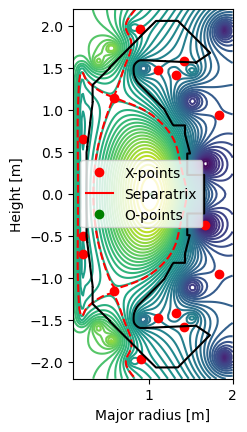

Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_optio

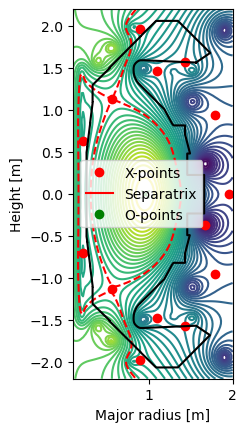

{'Solenoid': -15521.061278574336, 'px': 2016.2630220011315, 'd1': 3973.776334855837, 'd2': 4942.28070509305, 'd3': -2087.3755132032184, 'dp': -3771.631106105988, 'd5': -2018.3430809946824, 'd6': -446.8049220349658, 'd7': 1202.4723264410804, 'p4': -3388.909018187745, 'p5': -5610.990504739633, 'p6': -47.29386867855885, 'vessel_1': 0, 'vessel_2': 0, 'vessel_3': 0, 'vessel_4': 0, 'vessel_5': 0, 'vessel_6': 0, 'vessel_7': 0, 'vessel_8': 0, 'vessel_9': 0, 'vessel_10': 0, 'vessel_11': 0, 'vessel_12': 0, 'vessel_13': 0, 'vessel_14': 0, 'vessel_15': 0, 'vessel_16': 0, 'vessel_17': 0, 'vessel_18': 0, 'vessel_19': 0, 'vessel_20': 0, 'vessel_21': 0, 'vessel_22': 0, 'centrecolumn_1': 0, 'centrecolumn_2': 0, 'centrecolumn_3': 0, 'centrecolumn_4': 0, 'centrecolumn_5': 0, 'centrecolumn_6': 0, 'centrecolumn_7': 0, 'centrecolumn_8': 0, 'centrecolumn_9': 0, 'centrecolumn_10': 0, 'd1_support_upper_1': 0, 'd1_support_upper_2': 0, 'd1_support_upper_3': 0, 'd1_support_lower_1': 0, 'd1_support_lower_2': 0, 'd

{0: {'index': 0,
  'shape_matrix': array([[ 8.28099292e-11,  1.10249854e-10,  1.29213754e-10,
           1.93130817e-10,  5.04540747e-10,  1.15216974e-09,
           2.31531744e-09, -1.60875408e-08],
         [ 1.43189189e-06,  3.80028524e-06,  4.66456205e-06,
           7.38589942e-06,  1.63043775e-05,  5.14103353e-05,
           1.17763967e-04,  2.82628392e-07],
         [ 1.92057143e-05,  1.79625857e-05,  1.44793802e-05,
           1.49686094e-05,  3.93270450e-05,  5.44846000e-05,
           7.16354767e-05,  1.64936898e-05],
         [ 4.95923339e-06,  1.81018843e-05,  3.18813139e-05,
           3.90736821e-05,  4.18320872e-05,  2.89473207e-05,
           3.26387524e-05, -1.23229964e-06]]),
  'vc_matrix': array([[ 2.41807270e+07, -1.22331826e+04,  2.30111917e+04,
          -1.22746801e+04],
         [ 8.21525331e+06, -5.61474751e+03,  8.21909390e+03,
          -6.39647307e+02],
         [-1.05384959e+07,  2.19419761e+03, -9.27698593e+03,
           1.28687001e+04],
         [-1.8434

In [49]:
def save_vc_sequence(
    equi_list, profiles_list, coils, targets, solver, save_path="./test_saves"
):
    """open shot pickle, solve equis, compute VC, save as hdf5 and pickle"""
    VCH = vc.VirtualCircuitHandling()
    VCH.define_solver(solver, target_relative_tolerance=1e-7)

    # dict to save data to
    big_dict = {}

    timestamp_list = []
    # for i in range(len(equi_list)):
    for i in range(3):
        # for i in [3]:
        try:
            print(f"doing equilibrium {i} from list")
            eq = equi_list[i]
            profiles = profiles_list[i]
            print(eq.tokamak.getCurrents())
            plot_eqi(eq, show=True)

            time_calc = 0.1 * i  # dummy time variable
            time_stop = 0.1 * (i + 1)
            input_currents = np.random.rand(len(equi_list[i].tokamak.getCurrents()))
            input_profile_pars = np.random.rand(5)

            VCH.calculate_VC(
                eq=eq,
                profiles=profiles,
                coils=coils,
                targets=targets,
                targets_options=None,
                # name=f"test_vc_{i}",
            )
            virtual_circuit = VCH.latest_VC  # get the latest VC
            print("plotting equi again")
            plot_eqi(eq, show=True)
            print(eq.tokamak.getCurrents())

            # extract attributes
            shape_mat = virtual_circuit.shape_matrix
            targets_val = virtual_circuit.targets_val
            vc_mat = virtual_circuit.VCs_matrix

            dict_temp = {
                "index": i,
                "shape_matrix": shape_mat,
                "vc_matrix": vc_mat,
                "targets": targets,
                "coils": coils,
                "time_calc": time_calc,
                "time_stop": time_stop,
                "targets_val": targets_val,
                "input_currents": input_currents,
                "input_profile_pars": input_profile_pars,
            }

            timestamp_list.append(time)
            big_dict[i] = dict_temp

        except Exception as e:
            print("ISSUE computing VC - moving to next equilibrium")
            print(e)

    # with h5py.File(save_path + "/test_vc_data.h5", "w") as f:
    #     # save  hdf5 parts
    #     for i, item in big_dict.items():
    #         print("big dict items")
    #         print(i)
    #         print(item)
    #         group = f.create_group(f"time_step_{i}")
    #         # group.create_dataset("targets", targets)
    #         # group.create_dataset("coils", coils)
    #         group.create_dataset("shape_matrix", data=item[shape_mat])
    #         group.create_dataset("vc_matrix", data=item[vc_mat])
    #         group.create_dataset("targets", data=item[targets])
    #         group.create_dataset("coils", data=item[coils])
    #         group.create_dataset("time", data=item[time])
    #         group.create_dataset("targets_val", data=item[targets_val])
    #         group.create_dataset("input_currents", data=item[input_currents])
    #         group.create_dataset("input_profile_pars", data=item[input_profile_pars])
    #         group.attrs["time"] = item[time]

    #     f.create_dataset("timestamps", data=timestamp_list)

    # save as pickle
    with open("./test_saves/test_vc_set.pkl", "wb") as fp:
        pickle.dump(big_dict, fp)
        print("vc's saved to pickle")

    return big_dict


# test
targets = ["R_in", "R_out", "Rx_lower", "Rs_lower_outer"]
coils = ["px", "d1", "d2", "d3", "dp", "p4", "p5", "p6"]
big_dict = save_vc_sequence(
    equi_list=eqi_list,
    profiles_list=profiles_list,
    coils=coils,
    targets=targets,
    solver=solver,
)

big_dict

In [50]:
vc_sequence = scheduler.VirtualCircuitSequence(
    "/Users/alasdair.ross/Documents/HARTREE/freegsnke/examples/test_saves/test_vc_set.pkl"
)

# pick equilibrium
index = 1
eq = eqi_list[index]
profiles = profiles_list[index]


# pick corresponding VC
VC = vc_sequence.retrieve_vc(time_stamp=index * 0.5)
print(VC.targets)
# get target values from VC
targ_values = VC.targets_val
targs_req = targ_values * 1.002

print("target shifts we want will be ", targs_req - targ_values)

loading vcs from file
loading VC's from pickle file
there are 3 VC's loaded
['R_in', 'R_out', 'Rx_lower', 'Rs_lower_outer']
target shifts we want will be  [0.00062143 0.00277262 0.00112877 0.00159152]


In [51]:
# set example of targets and coils
test_targs_1 = ["R_in", "R_out", "Rx_lower", "Rs_lower_outer"]
test_targs_2 = ["R_in", "R_out", "Rx_lower"]

# example target observed and desire values (gives target deltas)
test_targs_1_obs = np.array([0.995, 0, 0, 0])
test_targs_1_req = np.array([1, 0, 0, 0])

test_targs_2_obs = np.array([0.995, 0, 0])
test_targs_2_req = np.array([1, 0, 0])

# example sets of coils
test_coils_1 = ["px", "d1", "d2", "d3", "dp", "p4", "p5", "p6"]
test_coils_2 = ["px", "d1", "d2", "d3", "dp", "d5", "d6", "d7", "p4", "p5"]

In [52]:
## Build example target schedule, target sequence.

# saving to pickle

target_seq_dict = {
    "R_in": {"times": [0.1, 0.2, 0.3, 0.4, 0.5], "vals": [0.1, 0.11, 0.12, 0.13, 0.14]},
    "R_out": {"times": [0.1, 0.25, 0.35, 0.55], "vals": [1, 0.99, 0.98, 0.0]},
    "Rx_lower": {"times": [0.1], "vals": [1]},
    "Rs_lower_outer": {"times": [0.1, 0.2], "vals": [1, 1.2]},
}

pickle.dump(target_seq_dict, open("./test_saves/target_sequence.pkl", "wb"))

target_schedule_dict = {
    0.1: ["R_in", "R_out", "Rx_lower", "Rs_lower_outer"],
    0.15: ["R_in"],
    0.2: ["R_in", "R_out"],
    0.25: ["R_out"],
    0.3: ["R_in", "R_out"],
    0.35: ["R_in", "R_out"],
    0.4: ["R_in", "R_out"],
    0.45: ["R_in", "R_out"],
    0.5: ["R_in", "R_out"],
}

pickle.dump(target_schedule_dict, open("./test_saves/target_schedule.pkl", "wb"))

In [53]:
TS = scheduler.TargetSequencer(
    target_sequence_path="./test_saves/target_sequence.pkl",
    target_schedule_path="./test_saves/target_schedule.pkl",
    vc_flag="file",
    vc_schedule_path="./test_saves/test_vc_set.pkl",
)

loading target schedule from pickle file
target schedule times [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5 ]
target schedule dict {0.1: ['R_in', 'R_out', 'Rx_lower', 'Rs_lower_outer'], 0.15: ['R_in'], 0.2: ['R_in', 'R_out'], 0.25: ['R_out'], 0.3: ['R_in', 'R_out'], 0.35: ['R_in', 'R_out'], 0.4: ['R_in', 'R_out'], 0.45: ['R_in', 'R_out'], 0.5: ['R_in', 'R_out']}
loading target sequence from pickle file
loading vcs from file
loading VC's from pickle file
there are 3 VC's loaded
checking target schedule and vc sequence
checking compatibility of target schedule and vc sequence at time 0.1
checking order of targets
controlled targets ['R_in', 'R_out', 'Rx_lower', 'Rs_lower_outer']
VC available targets ['R_in', 'R_out', 'Rx_lower', 'Rs_lower_outer']
checking compatibility of target schedule and vc sequence at time 0.125
checking order of targets
controlled targets ['R_in', 'R_out', 'Rx_lower', 'Rs_lower_outer']
VC available targets ['R_in', 'R_out', 'Rx_lower', 'Rs_lower_outer']
checking co

In [55]:
# Control Voltages Handling
CVH = cv.ControlVoltages(eq, profiles, stepping=stepper, target_sequencer=TS)
CVH.feeback_voltage_control_timefunc(time_stamp=0.125, eq=eq, profiles=profiles)

number active coils 12
['Solenoid', 'px', 'd1', 'd2', 'd3', 'dp', 'd5', 'd6', 'd7', 'p4', 'p5', 'p6']
['d1', 'd2', 'd3', 'dp', 'd5', 'd6', 'd7', 'p4', 'p5']
initialising with default all active coils
Default targets and current's initialised
all active ['Solenoid', 'px', 'd1', 'd2', 'd3', 'dp', 'd5', 'd6', 'd7', 'p4', 'p5', 'p6']
control coilds ['d1', 'd2', 'd3', 'dp', 'd5', 'd6', 'd7', 'p4', 'p5']
controlled targets are  ['R_in', 'R_out', 'Rx_lower', 'Rs_lower_outer']
Gain matrix not provided, using identity matrix
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
updating coils to None
Virtual circuit provided
targets ['R_in', 'R_out', 'Rx_lower', 'Rs_lower_outer']
coils ['px', 'd1', 'd2', 'd3', 'dp', 'p4', 'p5', 'p6']
Observed targets not provided, calculating from equilibrium
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
[0.31071405 1.38631158 0.56438274 0.79575752]
target deltas [-0.20821405 -0.

(array([-12.21582263, -14.77410909,   5.7490796 ,  -5.2290555 ,
        -31.66174372,  47.04341338,   6.65693432,  16.34565435,
         13.25263752,  18.87601787,  10.57551968,  14.71108432]),
 array([  0.        , -14.77410909,   5.7490796 ,  -5.2290555 ,
        -31.66174372,  47.04341338,   0.        ,   0.        ,
          0.        ,  18.87601787,  10.57551968,  14.71108432]))

In [57]:
# TS.retrieve_controlled_targets(time_stamp=0.05)

TS.desired_target_values(time_stamp=0.23)
TS.vc_flag
print(TS.get_vc(eq=eq, profiles=profiles, time_stamp=0.23, coils=coils))

In [ ]:
# voltages with no VC provided
voltages_1_A, voltages_1_B = CVH.calculate_voltage_vc_feedback_proportional(
    eq_1,
    profiles_1,
    virtual_circuit=None,
    targets_req=test_targs_1_req,
    targets_obs=test_targs_1_obs,
    targets=test_targs_1,
)
print("--------\n example voltages 1 : no VC provided\n--------")
print(voltages_1_A)
print(voltages_1_B)

TypeError: ControlVoltages.calculate_voltage_vc_feedback_proportional() got an unexpected keyword argument 'target_names'

Now repeat with a different set of coils and targets, again with no VC provided

In [ ]:
CVH.feeback_voltage_control_timefunc(
    time_stamp=0.12,
    eq=eq,
    profiles=profiles,
)

In [ ]:
# voltage_handler.virtual_circuit.VCs_matrix
CVH.virtual_circuit.shape_matrix

If we are to provide a VC then we must make sure that we provide the correct targets and coils, and target values.
Let's load a VC sequence from the pickle file.

In [ ]:
pickle_vcs = pickle.load(
    open(
        "./test_saves/test_vc_set.pkl",
        "rb",
    )
)


print(pickle_vcs)

In [ ]:
vc_sequence = scheduler.VirtualCircuitSequence(
    vc_sequence_path="/Users/alasdair.ross/Documents/HARTREE/freegsnke/examples/test_saves/test_vc_set.pkl"
)

# pick equilibrium
index = 1
eq = eqi_list[index]
profiles = profiles_list[index]


# pick corresponding VC
VC = vc_sequence.retrieve_vc(time_stamp=index * 0.5)
print(VC.targets)
# get target values from VC
targ_values = VC.targets_val
targs_req = targ_values * 1.002

print("target shifts we want will be ", targs_req - targ_values)

In [ ]:
print("voltages when observed targets are not provided - computed from equi")
# repeat without providing observed targets
voltages_vc1a, voltages_vc2a = CVH.calculate_voltage_vc_feedback_proportional(
    eq,
    profiles,
    virtual_circuit=VC,
    targets_req=targs_req,
)

using emulator for vc 


In [ ]:
TS_emu = scheduler.TargetSequencer(
    target_sequence_path="./test_saves/target_sequence.pkl",
    target_schedule_path="./test_saves/target_schedule.pkl",
    vc_flag="Emulator",
    model_path="/Users/alasdair.ross/Documents/HARTREE/freegsnke-emu/experiments/MASTU_ANNfits/24_11_18_cleanedfits_geomtargets_AG",
)
CV_emu = cv.ControlVoltages(
    eq=eq, profiles=profiles, stepping=stepper, target_sequencer=TS_emu
)

In [ ]:
CV_emu.feeback_voltage_control_timefunc(eq=eq, profiles=profiles, time_stamp=0.1)

In [ ]:
CV_emu.feeback_voltage_control_timefunc(eq=eq, profiles=profiles, time_stamp=0.23)